# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [1]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [2]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "175996"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: v8f477052
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,50.566188,1.090991,-0.776800,0.080574,0.658805,0.936305,0.348204,-0.108802,0.315842,-2.307478,-1.102062,1.540189,-6.871735
1,26.595838,1.729492,1.538336,-0.403115,1.121270,0.957148,0.133794,-0.571903,-0.389526,-0.681767,-0.336052,1.700046,8.270109
2,44.462376,0.308098,-1.566509,-0.017972,1.015858,-0.251952,0.009875,-0.885133,-0.702104,-2.443094,0.008056,3.956795,4.765321
3,21.959332,3.228752,0.455506,0.211878,1.129830,2.634973,-0.470264,0.007923,1.580372,0.247736,1.792936,0.991508,29.216106
4,50.319596,2.369832,-0.416057,0.364288,0.309668,-1.071044,-0.421075,-0.382614,1.360409,-2.225250,-0.592473,0.211618,20.906619


In [3]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? ¿Hay faltantes?
train.describe().T

,count,mean,std,min,25%,50%,75%,max
x1,800.0,50.318308,30.081653,0.082714,23.312659,48.401362,77.086481,99.940296
x2,800.0,1.682271,2.004537,0.024374,0.526050,1.060128,2.066785,19.155278
x3,800.0,-0.006142,1.171418,-1.997506,-1.005294,0.018827,1.043802,1.995433
x4,800.0,0.001422,0.294600,-0.499441,-0.262710,-0.004354,0.265746,0.498798
x5,800.0,1.791491,2.486451,0.013698,0.537502,1.010962,2.085542,32.306036
x6,800.0,0.042070,1.698803,-2.999725,-1.390357,0.072070,1.526528,2.979357
x7,800.0,-0.007901,0.294776,-0.499555,-0.269155,0.005250,0.249422,0.499038
x8,800.0,-0.037258,1.008103,-3.423554,-0.725845,-0.039291,0.667711,3.176246
x9,800.0,0.045000,1.020735,-3.212342,-0.691665,0.089646,0.757767,3.264595
x10,800.0,0.018267,1.713587,-2.993891,-1.422144,0.138061,1.533910,2.995446


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 121.12
R² del baseline en validación : 0.476

Desviación estándar de y: 14.51


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

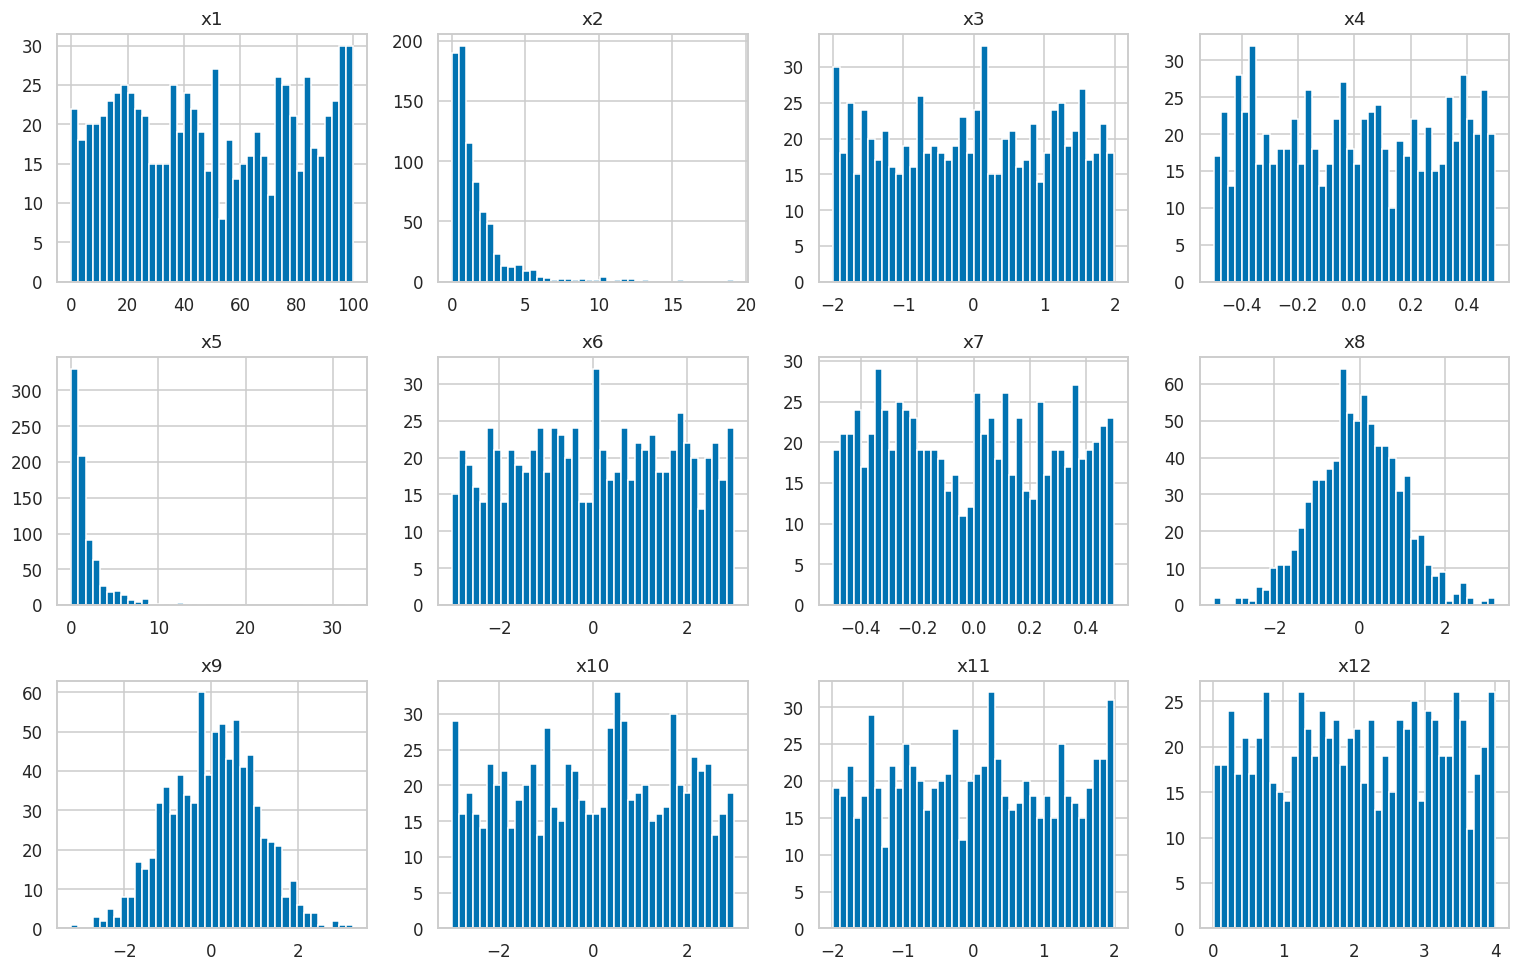

In [5]:
# TODO: distribución de cada una de las 12 variables.
# Pista de método: `train[VARIABLES].hist(...)` hace las 12 de un golpe.
train[VARIABLES].hist(bins=40, figsize=(14, 9), layout=(3, 4))
plt.tight_layout()
plt.show()

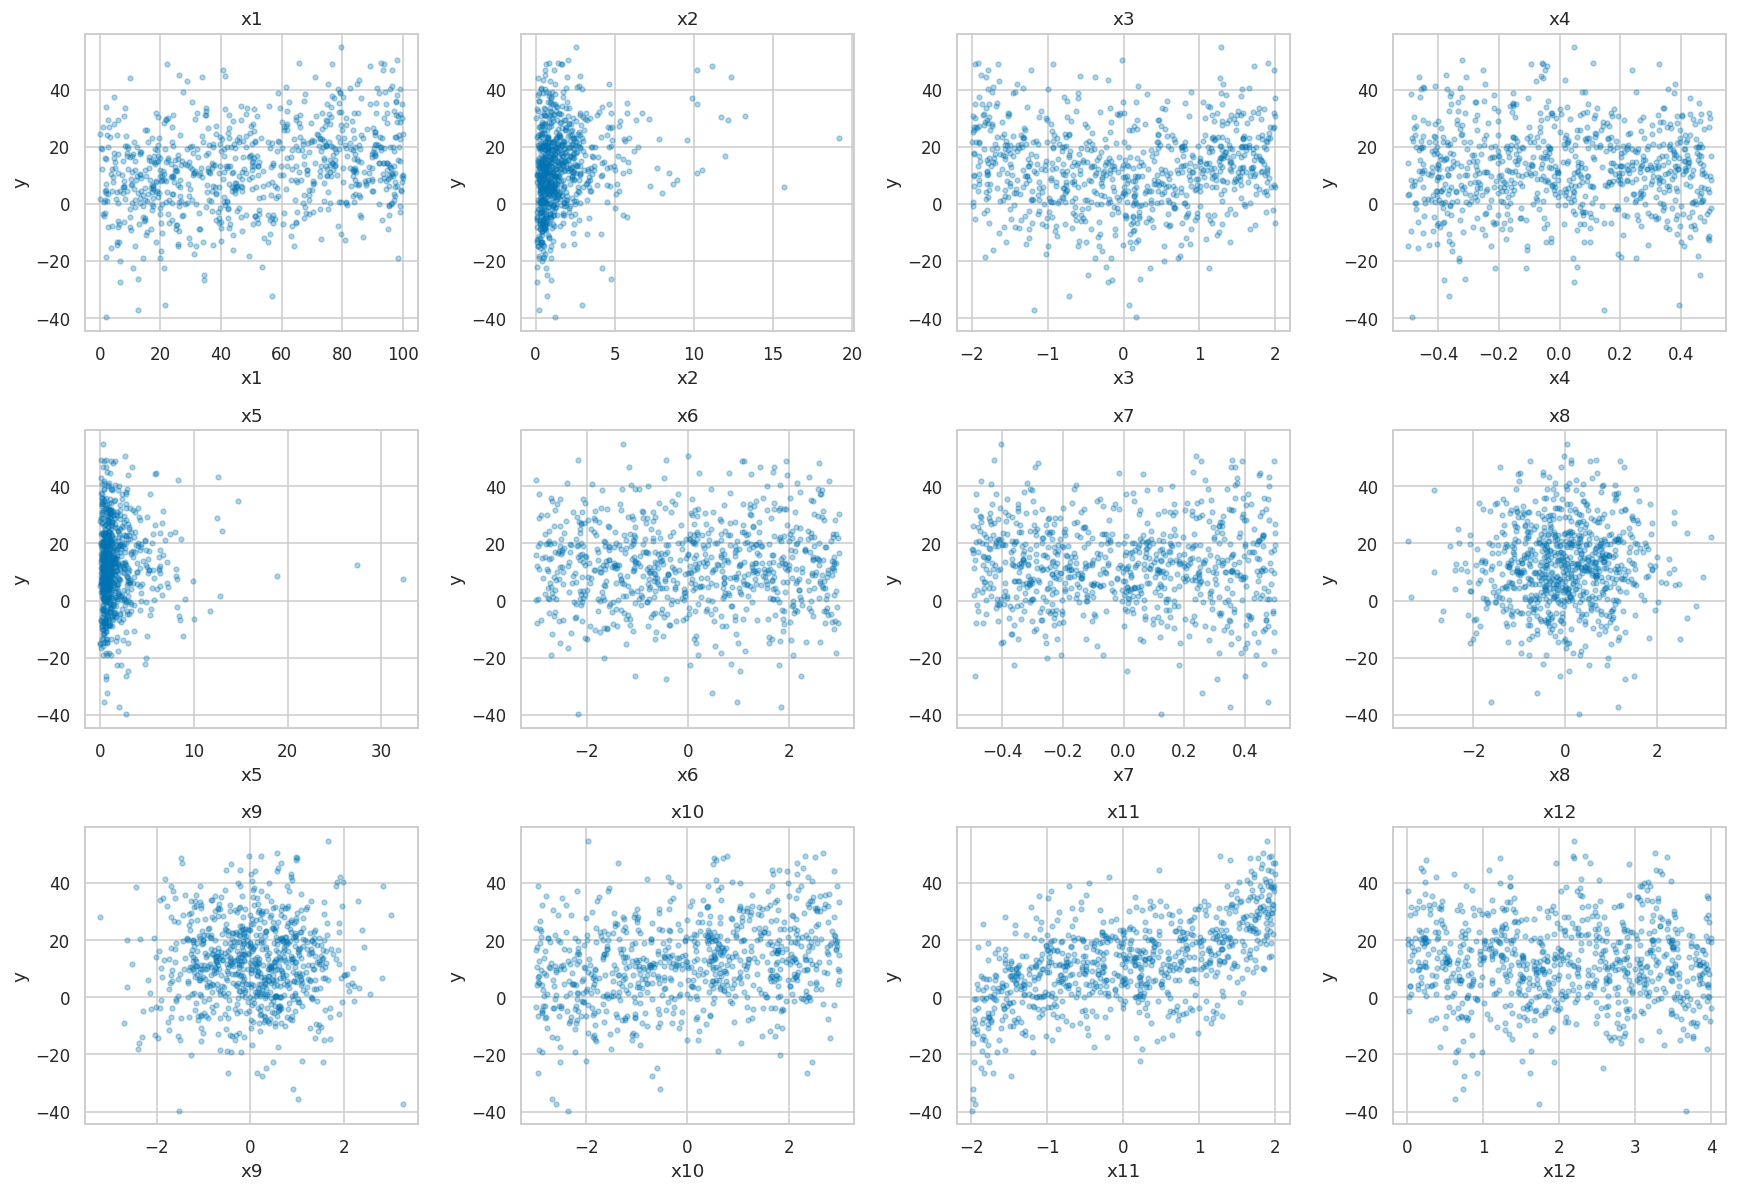

In [6]:
# TODO: `y` contra cada variable. Una rejilla de 12 paneles.
# Usen puntos con transparencia (`alpha`): con 800 observaciones se traslapan.
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, var in zip(axes.ravel(), VARIABLES):
    ax.scatter(train[var], train["y"], alpha=0.3, s=10)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()

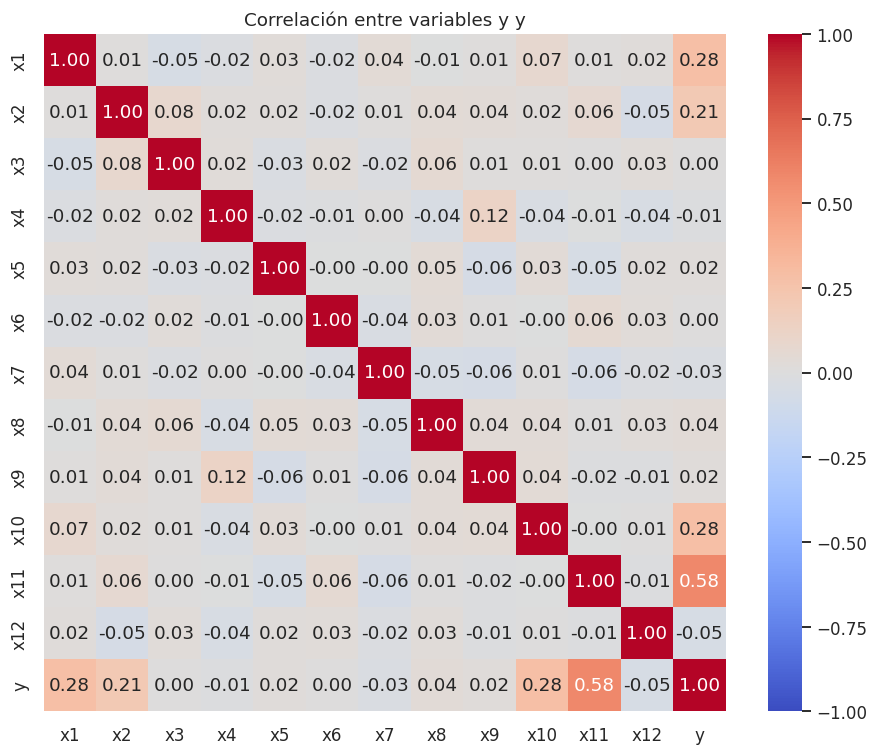

In [7]:
# TODO: matriz de correlación entre las 12 variables y `y`.
corr = train[VARIABLES + ["y"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlación entre variables y y")
plt.show()

### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` | Sube un poco (corr 0.28) | `y` vs `x1` | Poco |
| `x2` | Sube rápido cerca de 0 y luego se aplana: ¿logaritmo? | Histograma y `y` vs `x2` | Medio |
| `x3` | Forma de U (corr 0, pero sí hay algo) | `y` vs `x3` | Medio |
| `x4` | Nada | `y` vs `x4` | Medio |
| `x5` | Muy cargada a la izquierda como `x2`, ¿logaritmo? | Histograma | Poco |
| `x6` | Nada | `y` vs `x6` | Medio |
| `x7` | Nada | `y` vs `x7` | Poco |
| `x8` | Nada | `y` vs `x8` | Medio |
| `x9` | Nada | `y` vs `x9` | Medio |
| `x10` | Sube en línea recta (corr 0.28) | `y` vs `x10` | Medio |
| `x11` | La más fuerte (corr 0.58), forma de S | `y` vs `x11` | Alto |
| `x12` | Nada claro | `y` vs `x12` | Poco |

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [8]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 121.12


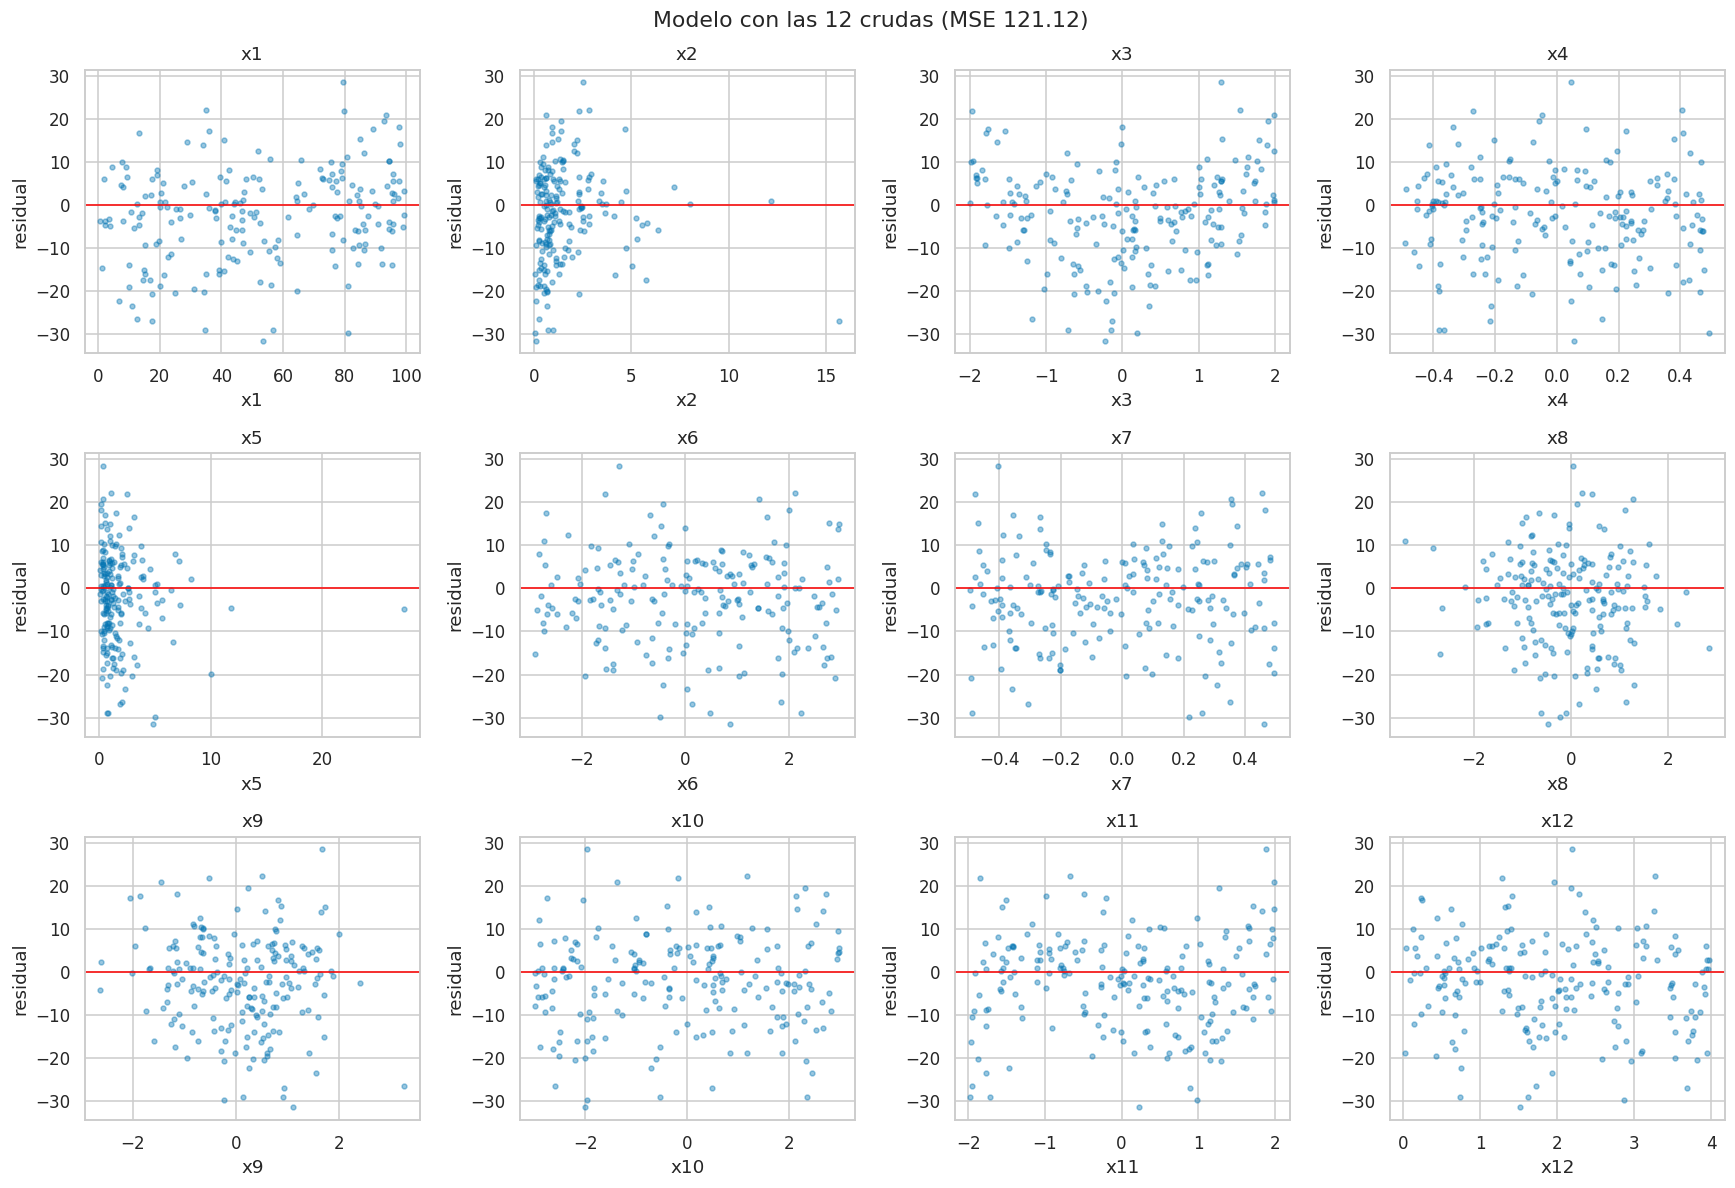

In [9]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
#
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.
def grafica_residuales(residuales, titulo=""):
    """Residuales de validación contra cada una de las 12 variables."""
    fig, axes = plt.subplots(3, 4, figsize=(16, 11))
    for ax, var in zip(axes.ravel(), VARIABLES):
        ax.scatter(X_val[var], residuales, alpha=0.4, s=10)
        ax.axhline(0, color="red", linewidth=1)
        ax.set_title(var)
        ax.set_xlabel(var)
        ax.set_ylabel("residual")
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()


grafica_residuales(residuales, f"Modelo con las 12 crudas (MSE {mse:.2f})")

MSE: 92.23


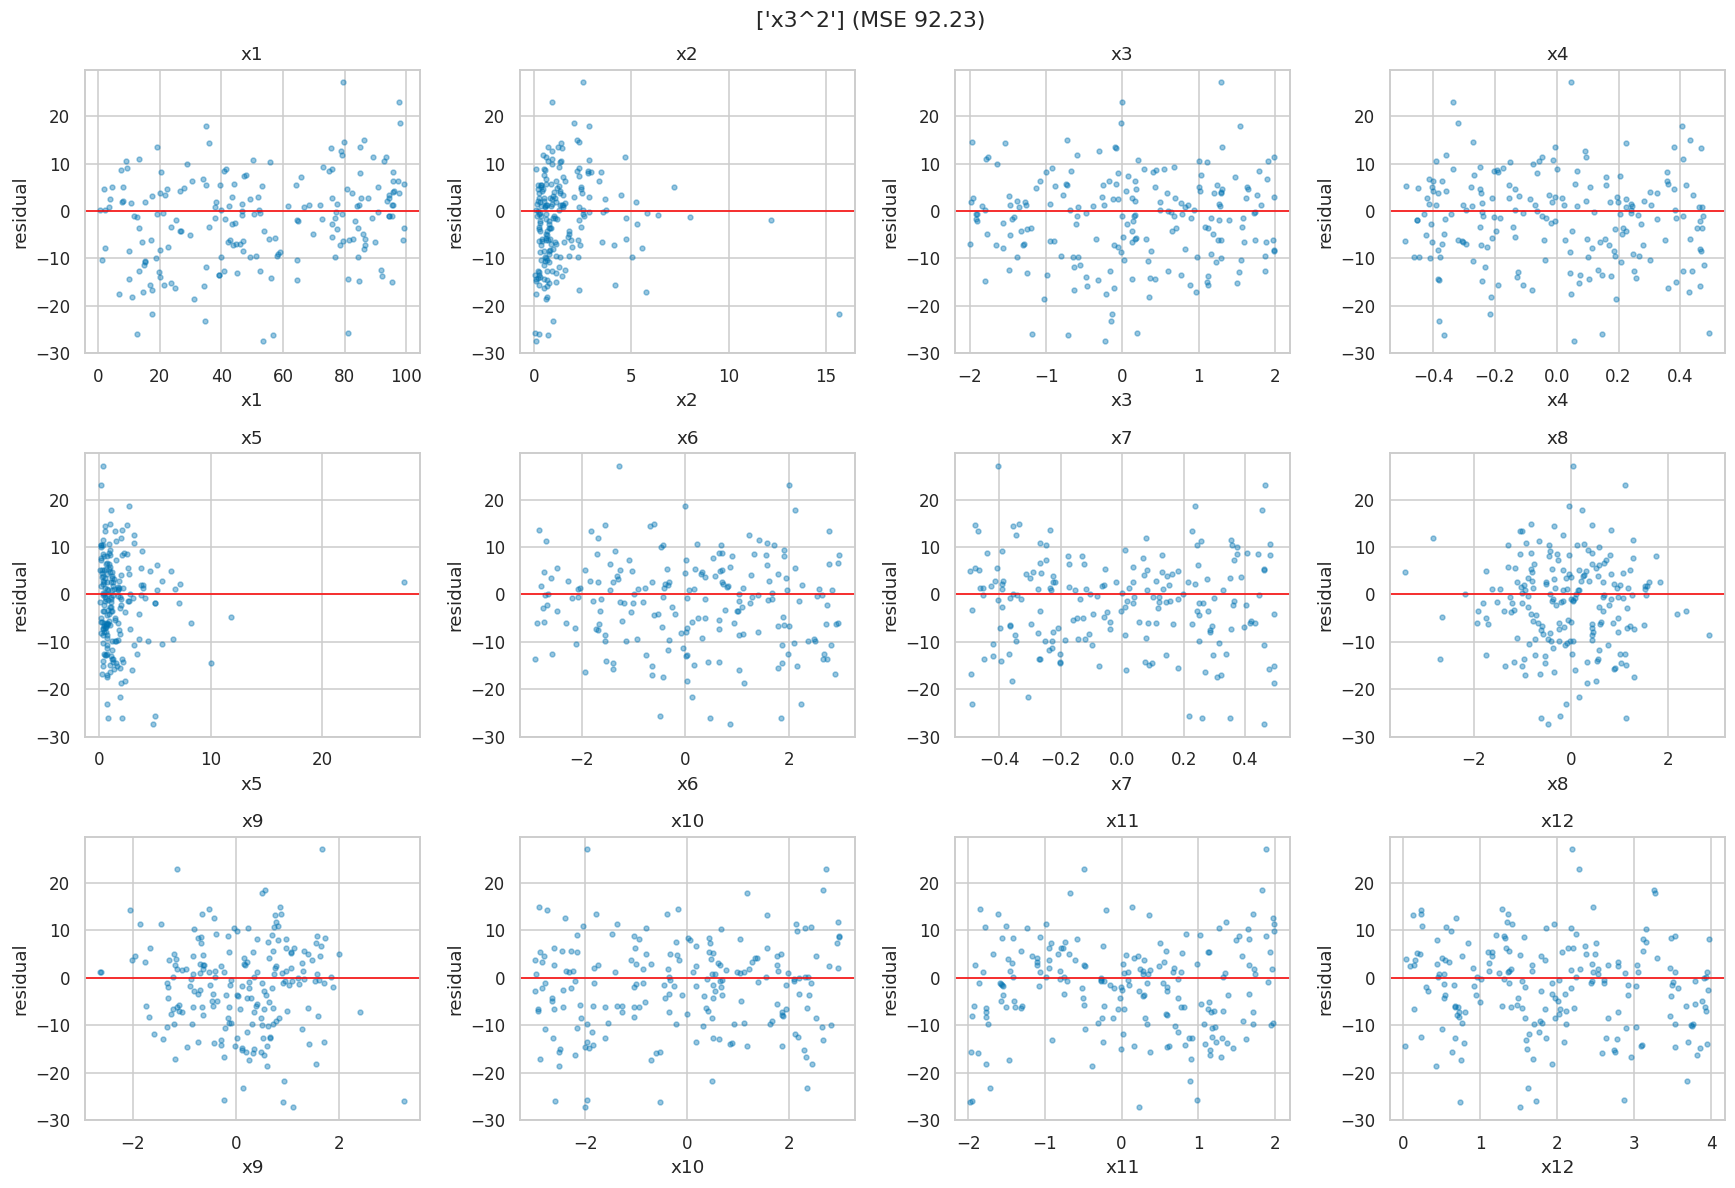

In [10]:
# TODO: agreguen su primer término y vuelvan a medir.
#
# Así se le pasa una columna derivada a `ajusta`. El término del ejemplo es deliberadamente
# absurdo y NO sirve para nada: solo ilustra la sintaxis del diccionario y del lambda.
#
# modelo, mse, residuales, _ = ajusta({"disparate": lambda d: d["x1"] + d["x2"]})
# print(f"MSE: {mse:.2f}")
#
# Si el MSE bajó mucho, iban bien. Si no se movió, ese término no era. Anoten las dos
# cosas en la bitácora: los intentos fallidos también cuentan.

# En los residuales, x3 hace una U (arriba en las orillas, abajo en medio).
# Una U es una parábola -> agrego x3 al cuadrado.
terminos = {
    # "nombre_del_termino": lambda d: ...,   <- escriban aquí su término
    "x3^2": lambda d: d["x3"] ** 2,
}

modelo, mse, residuales, _ = ajusta(terminos)
print(f"MSE: {mse:.2f}")
grafica_residuales(residuales, f"{list(terminos)} (MSE {mse:.2f})")

Paso 1: MSE 92.23


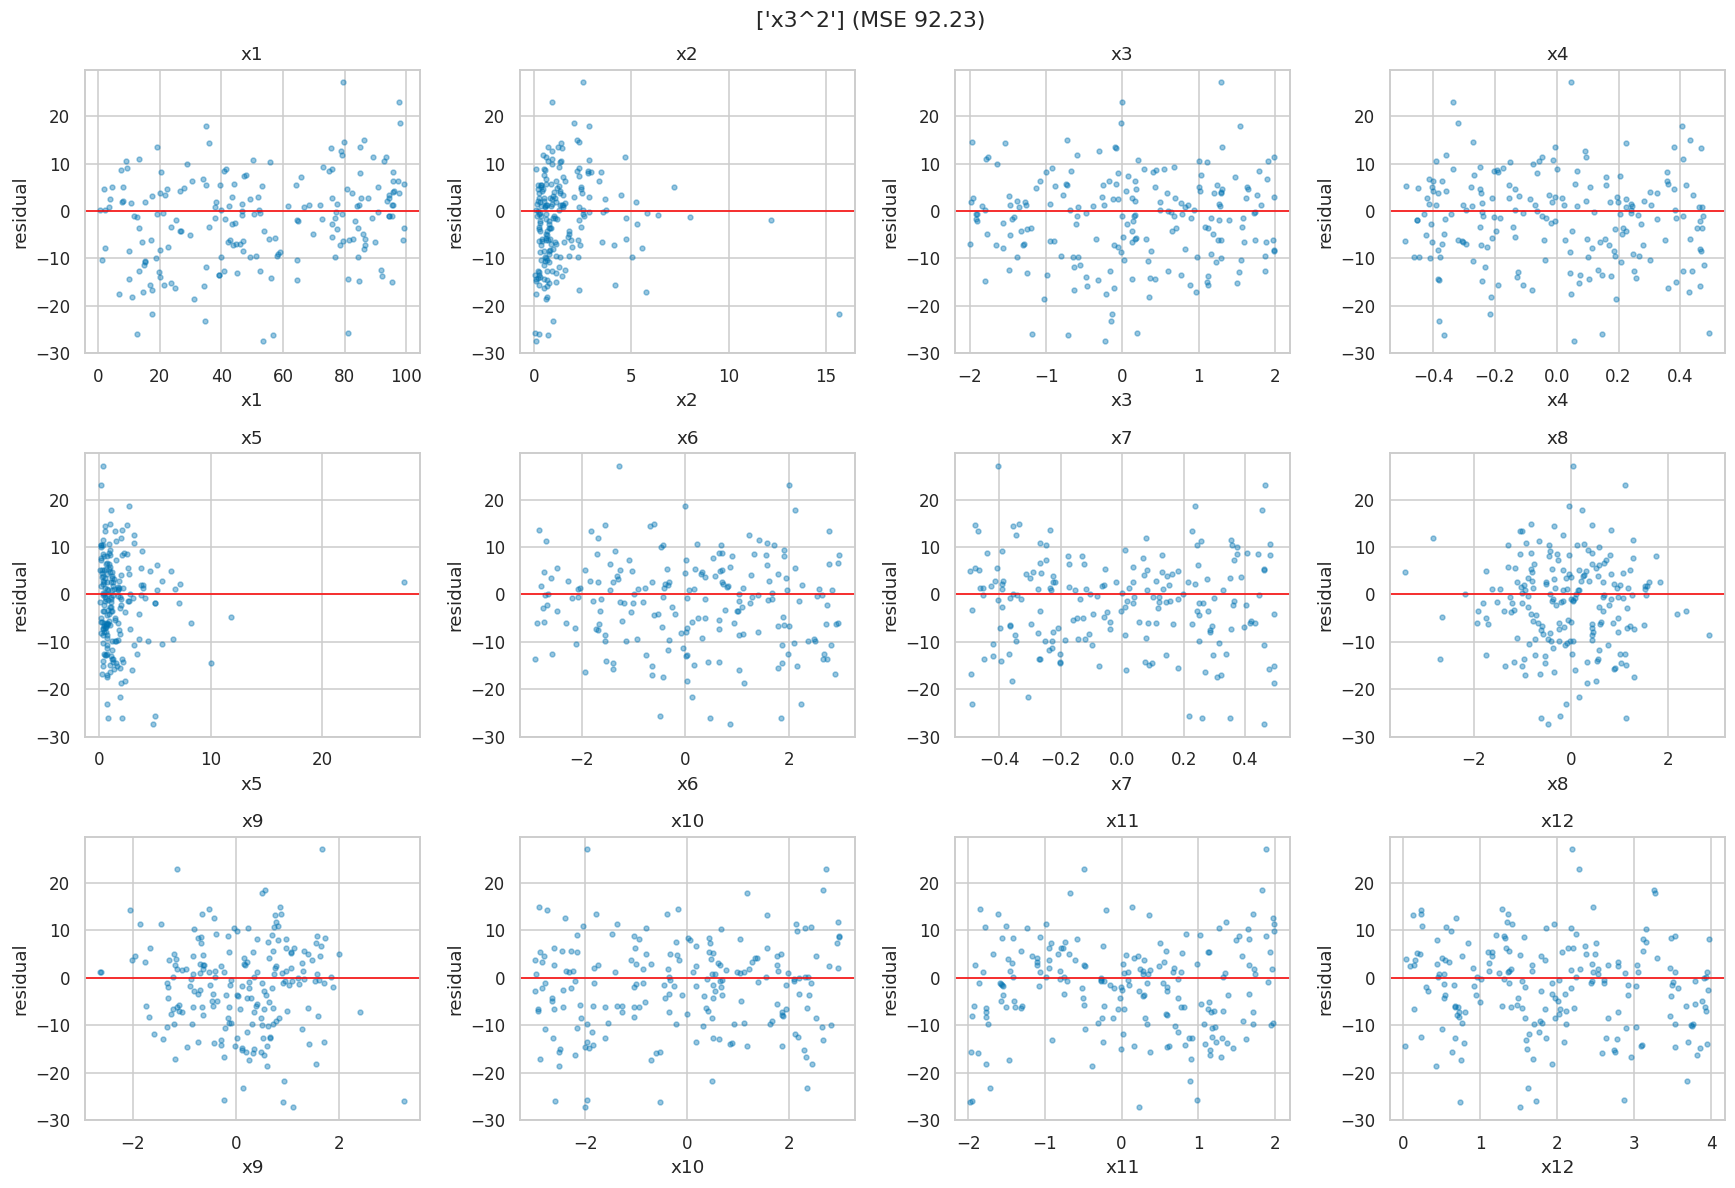

Paso 2: MSE 83.15


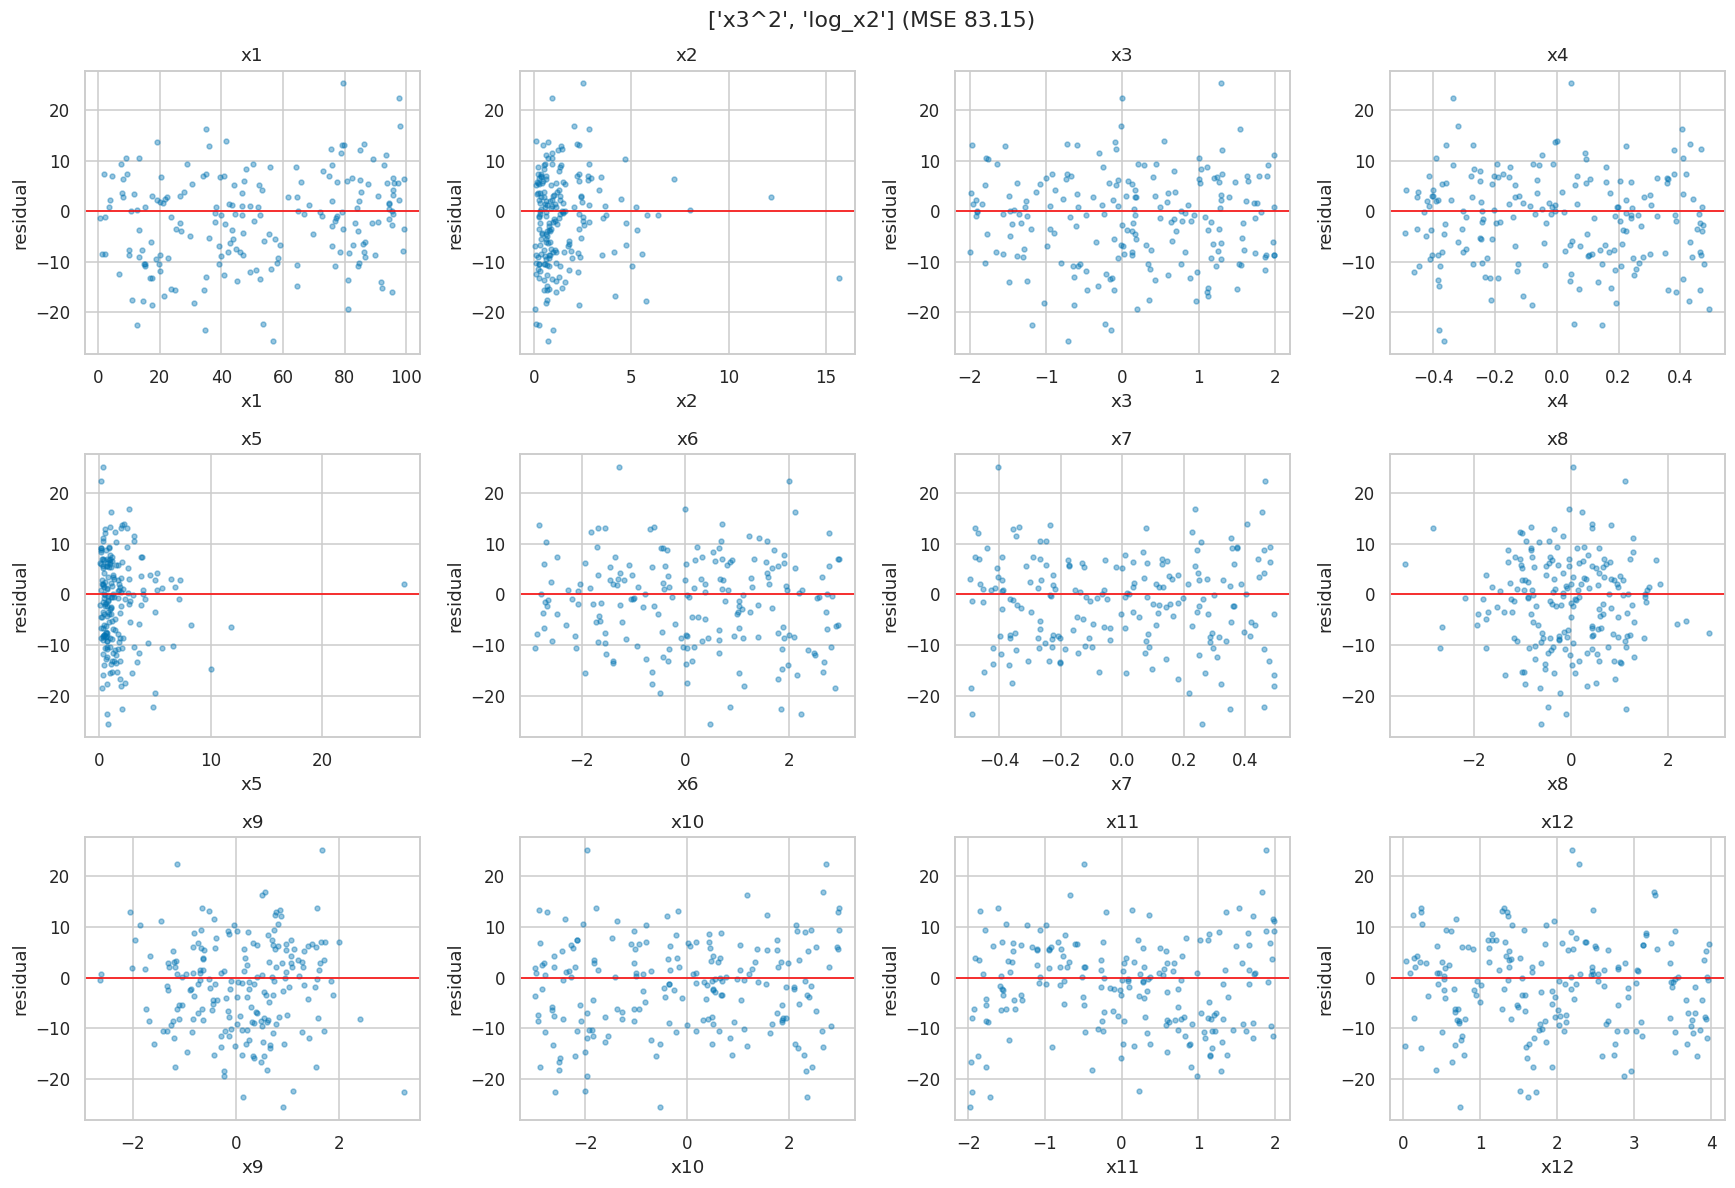

Con log(x5): MSE 83.23. No bajó, no lo uso.
Paso 3: MSE 67.19


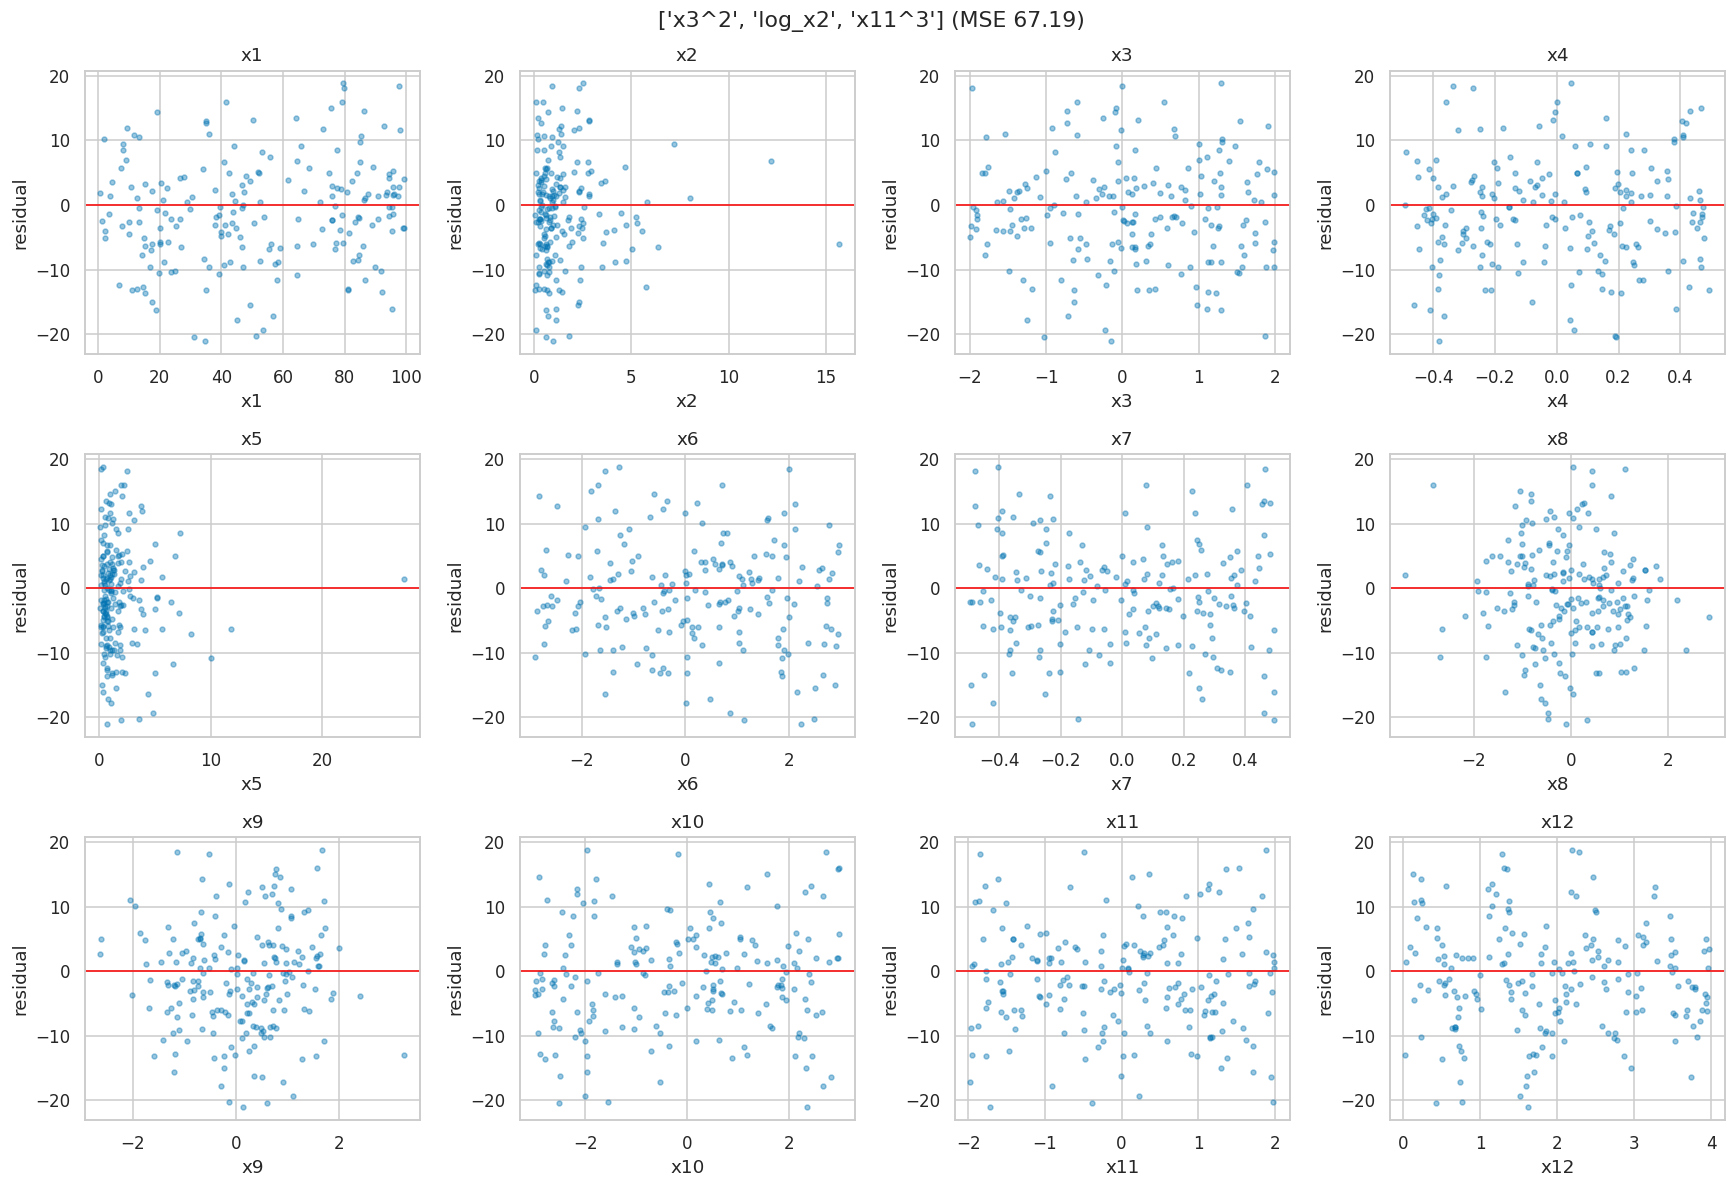

Seno con periodo 0.5: MSE 66.97
Seno con periodo 1: MSE 45.63
Seno con periodo 2: MSE 67.65
Paso 4: MSE 45.63


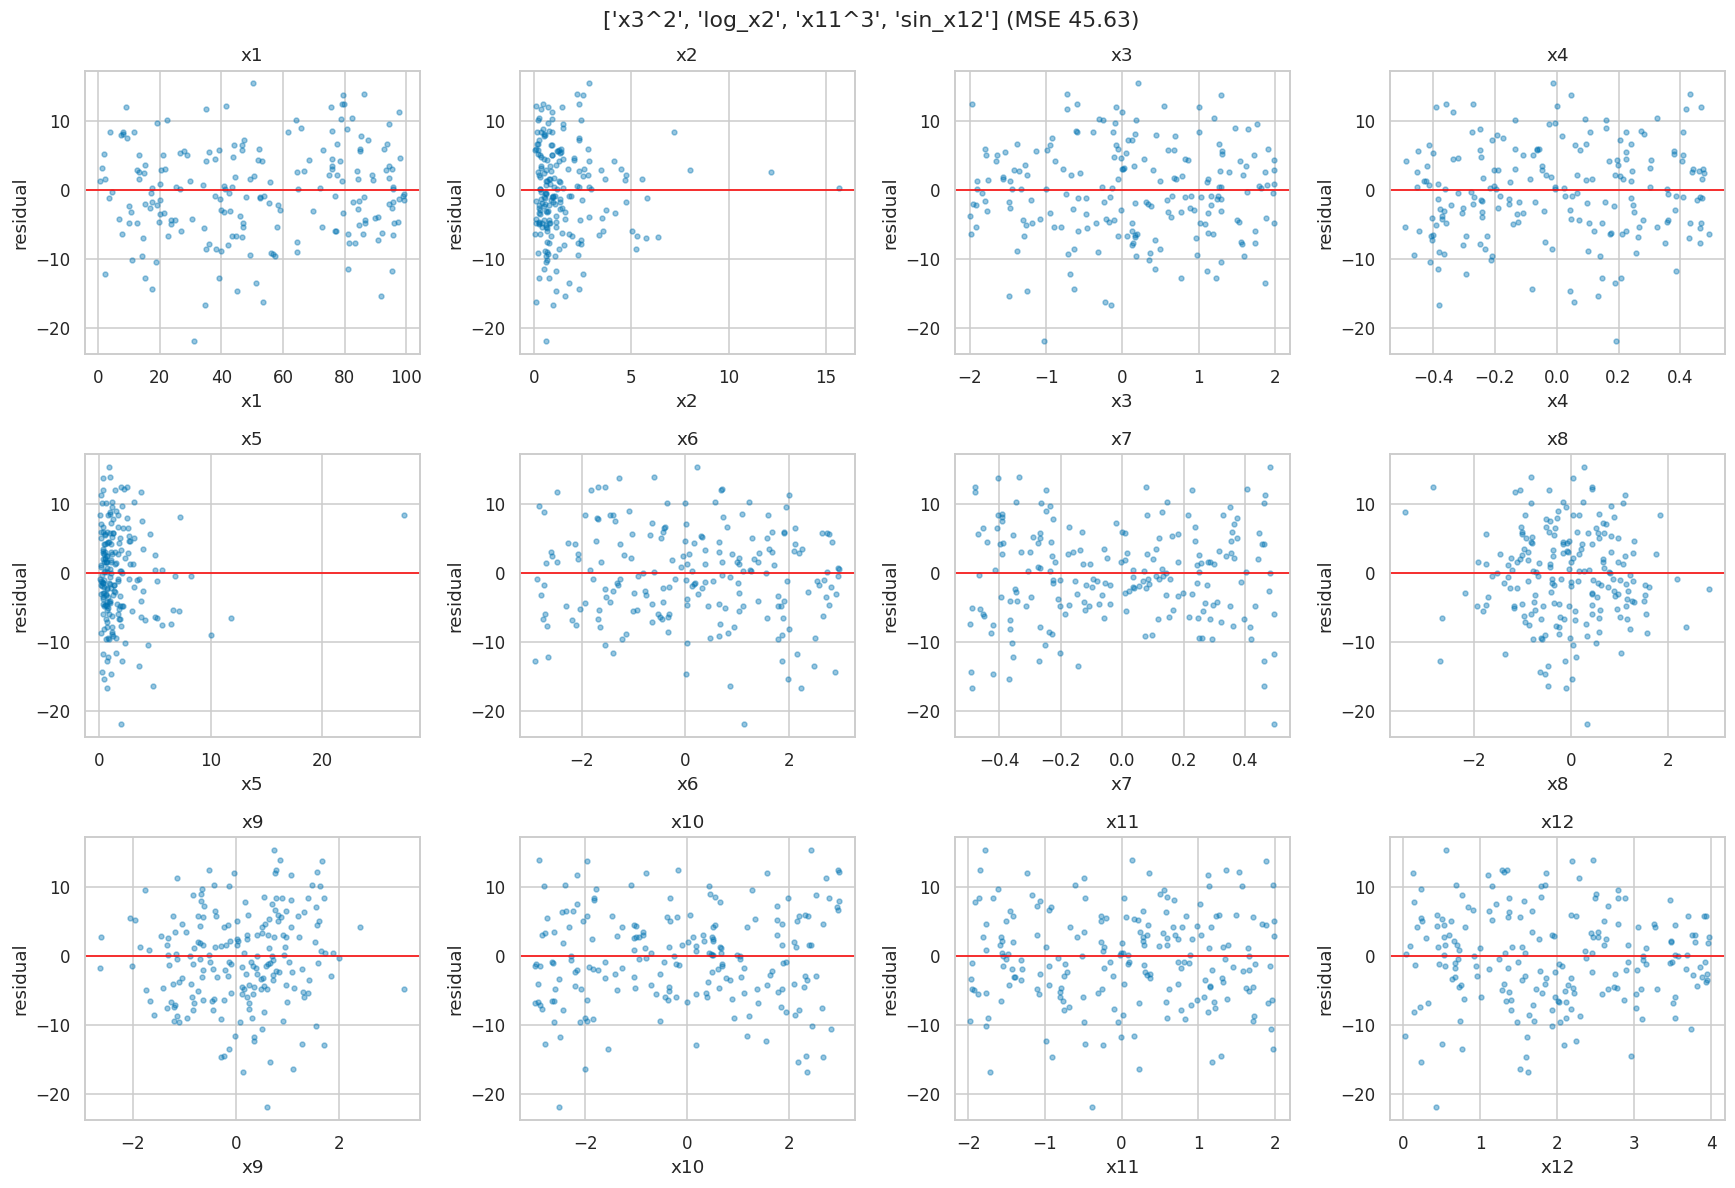

Escalón en 40: MSE 45.84
Escalón en 50: MSE 45.26
Escalón en 60: MSE 43.74
Escalón en 70: MSE 44.85
Escalón en 80: MSE 45.42
Paso 5: MSE 43.74


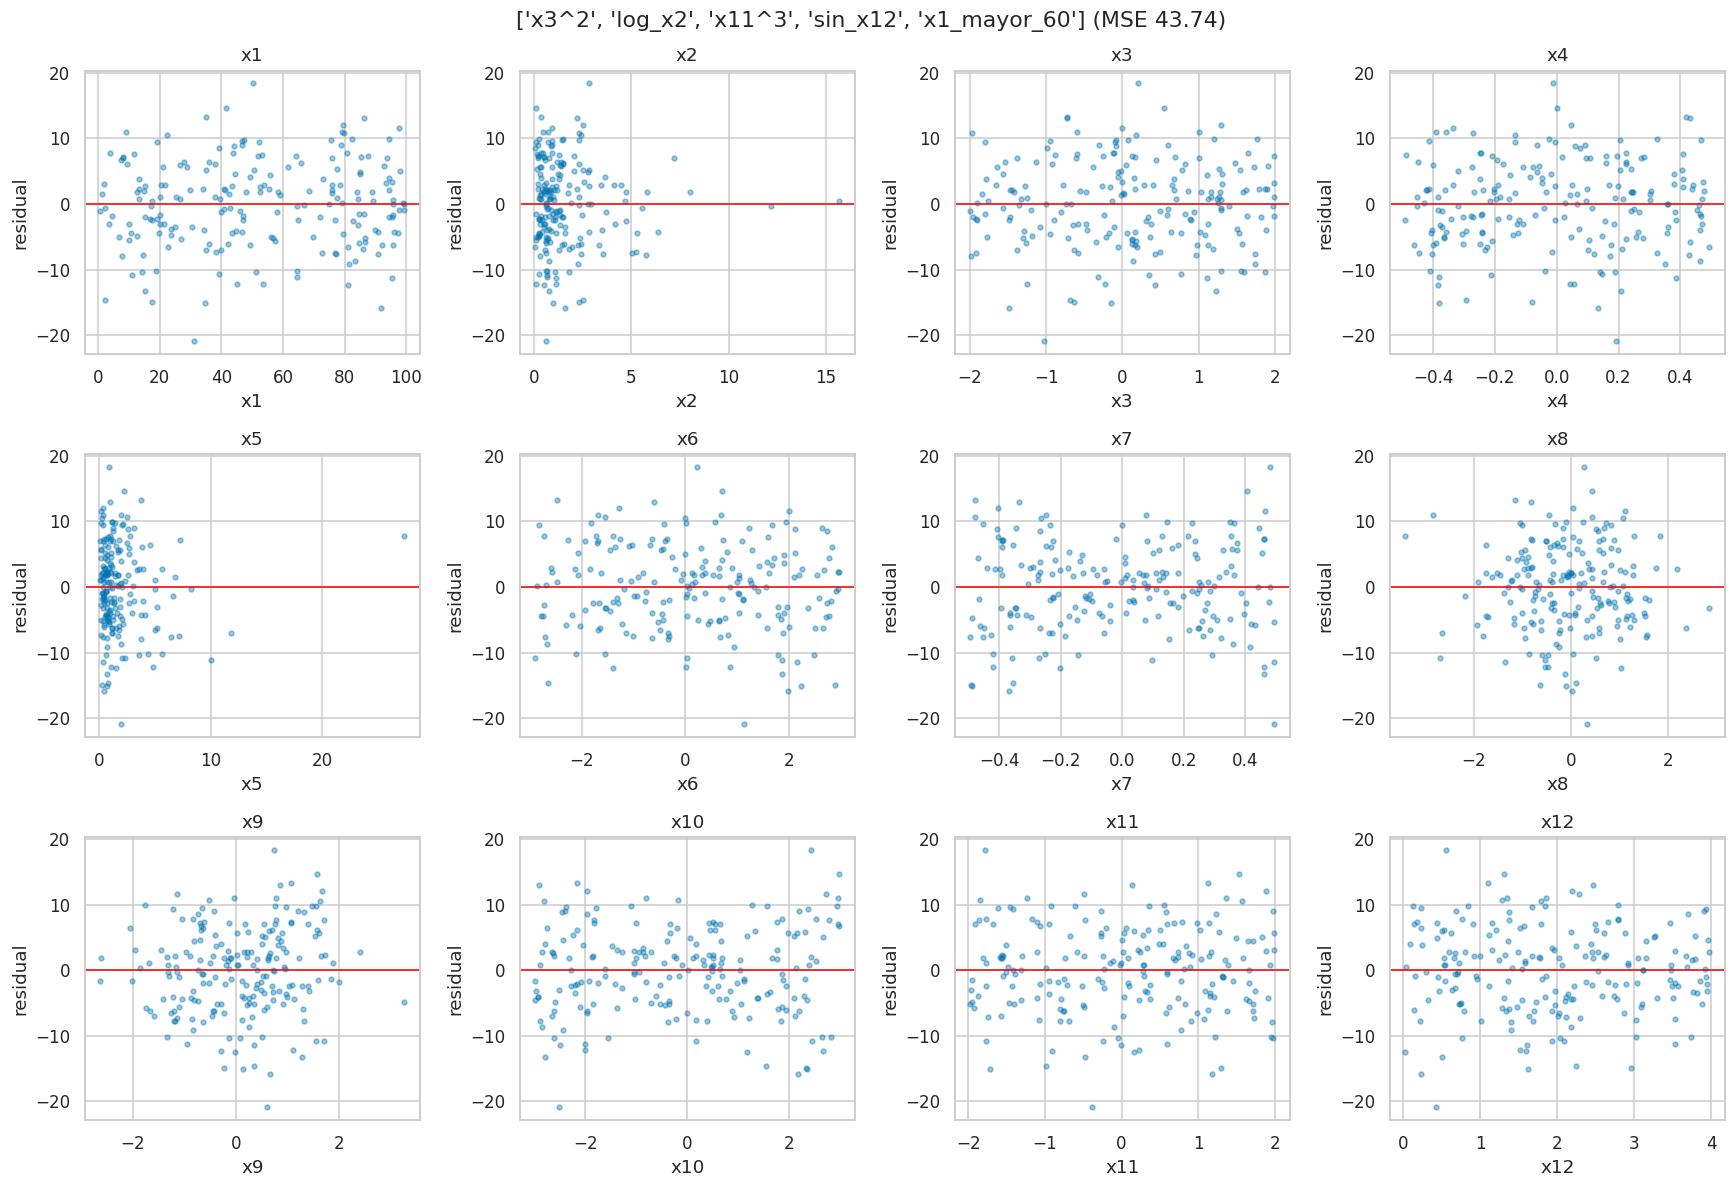

,paso,términos,MSE
0,0,"(ninguno, 12 crudas)",121.121292
1,1,x3^2,92.225184
2,2,"x3^2, log_x2",83.152815
3,3,"x3^2, log_x2, x11^3",67.191803
4,4,"x3^2, log_x2, x11^3, sin_x12",45.629426
5,5,"x3^2, log_x2, x11^3, sin_x12, x1_mayor_60",43.740961


In [11]:
# TODO: repitan el ciclo. Agreguen términos de uno en uno, graficando los residuales
# cada vez, hasta que ninguna gráfica tenga forma.
#
# Vayan guardando el MSE de cada paso: la bitácora de la Parte 5 lo pide.

historial = [{"paso": 0, "términos": "(ninguno, 12 crudas)", "MSE": ajusta()[1]}]


def paso(terminos):
    """Ajusta con `terminos`, guarda el MSE en `historial` y grafica residuales."""
    modelo, mse, residuales, _ = ajusta(terminos)
    historial.append({"paso": len(historial), "términos": ", ".join(terminos), "MSE": mse})
    print(f"Paso {len(historial) - 1}: MSE {mse:.2f}")
    grafica_residuales(residuales, f"{list(terminos)} (MSE {mse:.2f})")
    return modelo, mse, residuales


# Cada vuelta: copien el diccionario anterior, agréguenle UN término y llamen a `paso`.
# terminos = {**terminos, "nuevo_termino": lambda d: ...}
# modelo, mse, residuales = paso(terminos)

# Paso 1: x3 al cuadrado (la U)
modelo, mse, residuales = paso(terminos)

# Paso 2: x2 sube rápido cerca de 0 y luego se aplana -> logaritmo
terminos = {**terminos, "log_x2": lambda d: np.log(d["x2"])}
modelo, mse, residuales = paso(terminos)

# Intento fallido: x5 se ve igual que x2 en el histograma, ¿también logaritmo?
_, mse_x5, _, _ = ajusta({**terminos, "log_x5": lambda d: np.log(d["x5"])})
print(f"Con log(x5): MSE {mse_x5:.2f}. No bajó, no lo uso.")

# Paso 3: x11 hace una S -> al cubo
terminos = {**terminos, "x11^3": lambda d: d["x11"] ** 3}
modelo, mse, residuales = paso(terminos)

# Paso 4: ahora en x12 se ve una onda que sube y baja cada 1 unidad -> seno
for periodo in [0.5, 1, 2]:
    _, mse_p, _, _ = ajusta({**terminos, "seno": lambda d: np.sin(2 * np.pi * d["x12"] / periodo)})
    print(f"Seno con periodo {periodo}: MSE {mse_p:.2f}")
terminos = {**terminos, "sin_x12": lambda d: np.sin(2 * np.pi * d["x12"])}
modelo, mse, residuales = paso(terminos)

# Paso 5: en x1 los residuales dan un salto cerca de 60 -> escalón (0 antes, 1 después)
for corte in [40, 50, 60, 70, 80]:
    _, mse_c, _, _ = ajusta({**terminos, "escalon": lambda d: (d["x1"] > corte).astype(float)})
    print(f"Escalón en {corte}: MSE {mse_c:.2f}")
terminos = {**terminos, "x1_mayor_60": lambda d: (d["x1"] > 60).astype(float)}
modelo, mse, residuales = paso(terminos)
pd.DataFrame(historial)

---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

   producto        MSE
53   x7*x10  19.066537
51    x7*x8  42.924364
61   x9*x11  43.285223


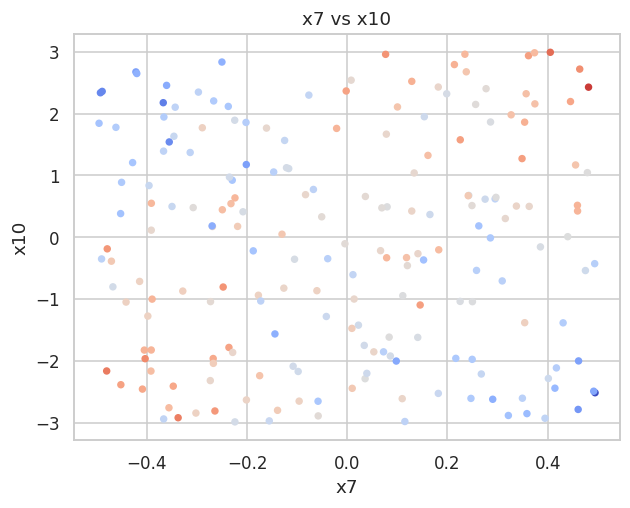

In [12]:
# TODO: exploren aquí.
#
# Son 66 pares de variables y no tienen que revisarlos a ciegas: usen lo que ya
# aprendieron en la Parte 2 para decidir por dónde empezar.
from matplotlib.colors import TwoSlopeNorm


def grafica_par(a, b, residuales, ax=None):
    """Una variable contra otra, con cada punto coloreado por su residual.

    Rojo = el modelo se quedó corto (residual positivo), azul = se pasó. Si el color
    se ordena en regiones (por ejemplo, rojo en dos esquinas opuestas y azul en las
    otras dos), hay un efecto conjunto de `a` y `b` que el modelo no tiene.
    """
    ax = ax or plt.gca()
    lim = np.abs(residuales).max()
    sc = ax.scatter(X_val[a], X_val[b], c=residuales, cmap="coolwarm",
                    norm=TwoSlopeNorm(0, -lim, lim), s=15)
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    ax.set_title(f"{a} vs {b}")
    return sc


# Ejemplo de uso con varios pares a la vez. Cambien la lista por los pares que
# quieran revisar; `residuales` es el de su último paso de la Parte 2.
# pares = [("x1", "x2"), ("x3", "x4")]
# fig, axes = plt.subplots(1, len(pares), figsize=(6 * len(pares), 5), squeeze=False)
# for ax, (a, b) in zip(axes.ravel(), pares):
#     sc = grafica_par(a, b, residuales, ax)
# fig.colorbar(sc, ax=axes.ravel().tolist(), label="residual")
# plt.show()

# Ya no se ve forma en ninguna variable sola, pero el MSE sigue alto.
# Puede haber dos variables que actúan juntas (un producto a*b).
# En vez de ver 66 gráficas, pruebo los 66 productos y veo cuál baja más el MSE.
resultados = []
for i, a in enumerate(VARIABLES):
    for b in VARIABLES[i + 1:]:
        _, mse_ab, _, _ = ajusta({**terminos, "producto": lambda d: d[a] * d[b]})
        resultados.append((f"{a}*{b}", mse_ab))
print(pd.DataFrame(resultados, columns=["producto", "MSE"]).sort_values("MSE").head(3))

# Gana x7*x10 por mucho. Lo confirmo con la gráfica del par:
grafica_par("x7", "x10", residuales)
plt.show()
# Rojo en dos esquinas opuestas y azul en las otras dos: sí es un producto.

Paso 6: MSE 19.07


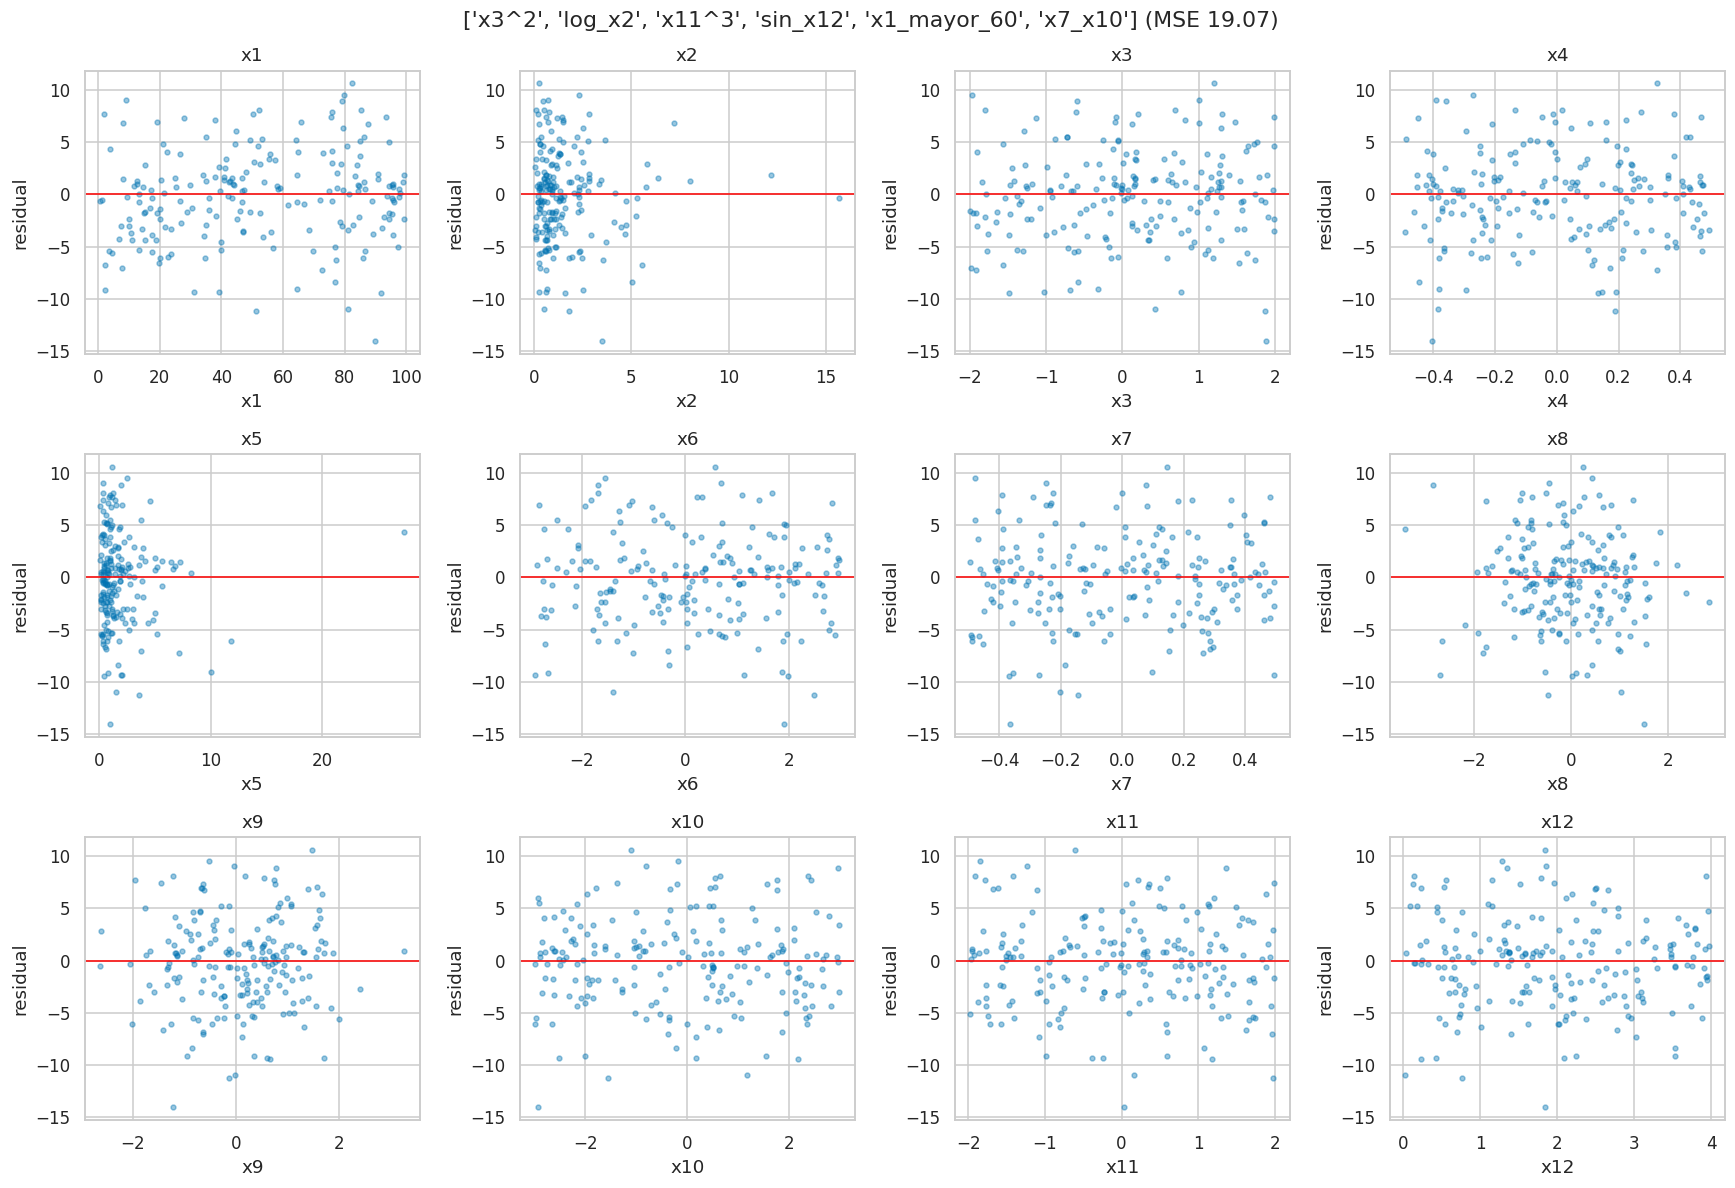

,paso,términos,MSE
0,0,"(ninguno, 12 crudas)",121.121292
1,1,x3^2,92.225184
2,2,"x3^2, log_x2",83.152815
3,3,"x3^2, log_x2, x11^3",67.191803
4,4,"x3^2, log_x2, x11^3, sin_x12",45.629426
5,5,"x3^2, log_x2, x11^3, sin_x12, x1_mayor_60",43.740961
6,6,"x3^2, log_x2, x11^3, sin_x12, x1_mayor_60, x7_x10",19.066537


In [13]:
# TODO: agreguen lo que hayan encontrado y midan.
# terminos = {**terminos, "nuevo_termino": lambda d: ...}
# modelo, mse, residuales = paso(terminos)
terminos = {**terminos, "x7_x10": lambda d: d["x7"] * d["x10"]}
modelo, mse, residuales = paso(terminos)
pd.DataFrame(historial)

In [14]:
# ¿Queda otro producto? Repito la búsqueda de los 66, ahora con x7*x10 ya adentro.
resultados = []
for i, a in enumerate(VARIABLES):
    for b in VARIABLES[i + 1:]:
        _, mse_ab, _, _ = ajusta({**terminos, "producto": lambda d: d[a] * d[b]})
        resultados.append((f"{a}*{b}", mse_ab))
print(f"MSE actual: {mse:.2f}")
print(pd.DataFrame(resultados, columns=["producto", "MSE"]).sort_values("MSE").head(3))

MSE actual: 19.07
   producto        MSE
33    x4*x8  18.860741
48   x6*x10  18.881755
42   x5*x10  18.894025


---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [15]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# TODO: camino B. Pipeline sugerido:
#   PolynomialFeatures(degree=3) -> StandardScaler -> LassoCV
#
# Estandaricen antes del Lasso: la penalización castiga coeficientes grandes, y sin
# estandarizar "grande" depende de las unidades de cada columna.
#
# Reporten el MSE de validación y cuántas columnas dejó distintas de cero.
from sklearn.pipeline import make_pipeline

fuerza_bruta = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LassoCV(cv=5, max_iter=50_000, random_state=SEMILLA, n_jobs=-1),
)
fuerza_bruta.fit(X_train, y_train)

mse_fb = mean_squared_error(y_val, fuerza_bruta.predict(X_val))
lasso = fuerza_bruta[-1]
nombres = fuerza_bruta[0].get_feature_names_out(VARIABLES)
no_cero = lasso.coef_ != 0

print(f"Columnas candidatas: {len(nombres)}")
print(f"Columnas distintas de cero: {no_cero.sum()}")
print(f"λ elegido: {lasso.alpha_:.4f}")
print(f"MSE de validación (fuerza bruta): {mse_fb:.2f}")

# Las columnas que el Lasso dejó vivas, de mayor a menor peso (estandarizado).
pd.Series(lasso.coef_[no_cero], index=nombres[no_cero]).sort_values(key=abs, ascending=False).head(20)

Columnas candidatas: 454
Columnas distintas de cero: 36
λ elegido: 0.4880
MSE de validación (fuerza bruta): 54.99


x11^3         7.669730
x7 x10        3.719430
x3^2          3.122325
x10           3.044452
x1^2          2.276226
x2            1.825860
x1 x3^2       0.951367
x7 x10 x12    0.726316
x7^2 x11      0.416405
x9^2 x11      0.381011
x3^2 x10      0.349023
x4 x9 x11     0.348672
x1^2 x2       0.314566
x4 x10 x11   -0.252431
x4^2 x11      0.216596
x1 x7^2       0.206938
x4 x5 x11    -0.164886
x4 x7 x12     0.126148
x7 x8 x12     0.116013
x3 x4 x8     -0.110880
dtype: float64

### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación?
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca.
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?
-------------------------------------------------------------------------------------
1. Mi modelo: MSE ≈ 19. La fuerza bruta: ≈ 55.
2. `PolynomialFeatures` solo hace potencias y productos (x², x³, x·y). Por eso encontró
   `x3²`, `x11³` y `x7·x10`, pero no puede hacer un logaritmo, un seno ni un escalón.
   Mi modelo sí los tiene porque los vi en las gráficas.
3. No aplica, ganó mi modelo.
4. Con 80 datos y 454 columnas, el Lasso no tendría suficiente información y se
   sobreajustaría (mucha varianza). Mi modelo solo tiene 18 columnas, así que
   aguantaría mejor.

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | `x3` hace una U | Residuales vs `x3` | `x3²` | 121.1 → 92.2 | Yo |
| 2 | `x2` necesita logaritmo | Residuales vs `x2` | `log(x2)` | 92.2 → 83.2 | Yo |
| 3 | `x5` también necesita logaritmo | Histograma de `x5` | ninguno, **no sirvió** | 83.2 → 83.2 | Yo |
| 4 | `x11` hace una S | Residuales vs `x11` | `x11³` | 83.2 → 67.2 | Yo |
| 5a | `x12` tiene una onda de periodo 0.5 | Residuales vs `x12` | ninguno, **no sirvió** | 67.2 → 67.0 (casi nada) | IA |
| 5b | `x12` tiene una onda de periodo 2 | Residuales vs `x12` | ninguno, **empeoró** | 67.2 → 67.7 | IA |
| 5c | `x12` tiene una onda de periodo 1 | Residuales vs `x12` | `sin(2π·x12)` | 67.2 → 45.6 | IA |
| 6a | `x1` tiene un salto en 40 | Residuales vs `x1` | ninguno, **empeoró** | 45.6 → 45.8 | IA |
| 6b | `x1` tiene un salto en 50, 70 u 80 | Residuales vs `x1` | ninguno, **casi nada** | 45.6 → 45.3 / 44.9 / 45.4 | IA |
| 6c | `x1` tiene un salto en 60 | Residuales vs `x1` | `1[x1 > 60]` | 45.6 → 43.7 | IA |
| 7 | Dos variables actúan juntas | Probar los 66 productos + `grafica_par` | `x7·x10` | 43.7 → 19.1 | Yo |
| 8 | Queda otro producto más | Probar los 66 productos otra vez | ninguno, **no sirvió**: el mejor fue `x4·x8` | 19.1 → 18.9 (casi nada) | IA |
| 9 | La fuerza bruta encuentra todo sola | `PolynomialFeatures(3)` + `LassoCV` (Parte 4) | ninguno, **perdió** contra mi modelo | 19.1 vs 55.0 | La tarea |

**Por qué descarté las que fallaron:**

- **3:** el histograma de `x5` se parece al de `x2`, pero eso solo dice cómo se reparten
  los valores, no si `x5` afecta a `y`. Con `log(x5)` el MSE no se movió.
- **5a y 5b:** un seno con el periodo equivocado no se alinea con la onda y casi no
  explica nada; el de periodo 2 hasta empeoró el MSE. Solo el periodo 1 coincidía con la
  onda que se ve en los residuales.
- **6a y 6b:** un escalón en el lugar equivocado deja del lado incorrecto del corte a
  los puntos que caen entre ese corte y 60. Por eso los cortes en 50 y 70, los más
  cercanos a 60, fueron los que menos perdieron, y el de 40 hasta empeoró el MSE.
- **8:** una mejora de 0.2 está dentro del ruido de la validación. Además, `x4` y `x8`
  no tienen efecto por sí solas, así que agregar su producto sería sobreajustar la
  validación.
- **9:** `PolynomialFeatures` solo arma potencias y productos. Encontró `x3²`, `x11³` y
  `x7·x10`, pero no puede armar el logaritmo, el seno ni el escalón. Con 36 columnas
  distintas de cero quedó peor que mi modelo, que tiene 18.

**Sospechas de la Parte 1 que resultaron falsas:**

- **`x7`: "nada".** Por sí sola no se ve, pero su producto con `x10` fue el segundo
  término que más bajó el MSE (43.7 → 19.1), solo detrás de `x3²`.
- **`x12`: "nada claro".** Tenía el seno, el tercer término que más bajó el MSE
  (67.2 → 45.6). En el scatter de `y` contra `x12` la onda estaba tapada por las demás
  variables; solo apareció en los residuales.
- **`x1`: "sube un poco".** Más que subir poco a poco, da un salto en 60.
- **`x5`: "¿logaritmo?".** No (ver fila 3).

### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

`y ≈ 3.6 + 1.4·x7 + 2.4·x10 + 3.7·x3² + 4.1·log(x2) + 2.9·x11³ + 6.3·sin(2π·x12) + 7.8·(x1 > 60) + 8.8·x7·x10 + ruido`

`x4`, `x5`, `x6`, `x8` y `x9` no sirven para nada (coeficiente ≈ 0).

### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

Después de agregar `x7·x10`, la IA me sugirió que podía quedar otro producto escondido
(fila 8). Repetí la búsqueda de los 66 productos y el mejor, `x4·x8`, solo bajó el MSE
de 19.07 a 18.86. Lo detecté comparando: `x7·x10` había bajado casi 25 puntos y este
apenas 0.2, más de cien veces menos, y además `x4` y `x8` no tienen efecto por sí solas.
La sugerencia era razonable en general, pero para mis datos no servía.

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

Paré porque ya ninguna gráfica de residuales tenía forma, ningún otro producto bajaba el
MSE de forma apreciable (el mejor, `x4·x8`, solo 0.2) y el MSE se quedó en ~19. *(Falta anotar aquí el MSE meta de `/validar`.)*

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [16]:
# TODO: pongan aquí las columnas derivadas de su modelo final, con el mismo formato
# que usaron en `ajusta`. Si su modelo final es el baseline crudo, déjenlo vacío.
MI_MODELO = {
    # "nombre_del_termino": lambda d: ...,
    "x3^2": lambda d: d["x3"] ** 2,
    "log_x2": lambda d: np.log(d["x2"]),
    "x11^3": lambda d: d["x11"] ** 3,
    "sin_x12": lambda d: np.sin(2 * np.pi * d["x12"]),
    "x1_mayor_60": lambda d: (d["x1"] > 60).astype(float),
    "x7_x10": lambda d: d["x7"] * d["x10"],
}


def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

MSE estimado (ajustado en train, medido en validación): 19.07

Escrito: entregas/tarea-01/v8f477052/predicciones.csv
400 predicciones, rango -22.28 a 53.21


### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.